# 7-ParallelEfficiency
This notebook evaluates the scaling of Dask, Spark, and DaskCuda dataframe libraries with respect to the number of cores and the file format of the data file ([csv](https://en.wikipedia.org/wiki/Comma-separated_values). vs. [parquet](https://parquet.apache.org/)). The executed notebooks with output and plots are saved in the [results directory](results). 

Note: this is not a representative comparison of these dataframe libraries.

See Robert Sinkovits' introduction to [Parallel Computing Concepts](https://github.com/sdsc/sdsc-summer-institute-2022/tree/main/2.1_parallel_computing_concepts).

Author: Peter W. Rose (pwrose@ucsd.edu)

In [1]:
import os
import time
import math
import shutil
import pandas as pd
import dask.dataframe as dd
import ipywidgets as widgets
import papermill as pm
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

If LOCAL_SCRATCH_DIR environment variable is not set, this notebook accesses the ../data directory for temporary files.

In [2]:
DATA_DIR = os.getenv("LOCAL_SCRATCH_DIR", default="../data")
filename = os.path.join(DATA_DIR, "gene_info.tsv")
file_size = f"{os.path.getsize(filename)/1E9:.1f}"
RESULTS_DIR = "results"

In [3]:
print(f"Filename: {filename}")
print(f"File Size: {file_size} GB")
print(f"Benchmark results directory: {RESULTS_DIR}")

Filename: /scratch/mkandes/job_51485094/gene_info.tsv
File Size: 6.5 GB
Benchmark results directory: results


## Setup Benchmark

#### Specify the number of cores to be used for benchmarking

The ```n_cores```, ```file_format```, and ```dataframe``` parameter are used for benchmarking ([see](7-ParallelEfficiency.ipynb)). 
The Cell below has been [parameterized](https://papermill.readthedocs.io/en/latest/usage-parameterize.html) as input parameters for [papermill](https://papermill.readthedocs.io/en/latest/index.html).

In [4]:
# Cell has a ```parameters``` tag. Papermill can set these variables.
n_cores = 8
file_format = "csv"
dataframe = "Dask"

In [5]:
cores = [2**i for i in range(0, round(math.log2(n_cores)+1))]
print(cores)

[1, 2, 4, 8]


In [6]:
style = {'description_width': "initial"}
f_widget = widgets.RadioButtons(options=["csv", "parquet"], description="Select input file format:", value=file_format, style=style)
d_widget = widgets.RadioButtons(options=["Pandas", "Dask", "Spark", "Cuda", "DaskCuda"], description="Select dataframe library:", value=dataframe, style=style)

#### Select input format and dataframe library

In [7]:
display(f_widget, d_widget)

RadioButtons(description='Select input file format:', options=('csv', 'parquet'), style=DescriptionStyle(descr…

RadioButtons(description='Select dataframe library:', index=1, options=('Pandas', 'Dask', 'Spark', 'Cuda', 'Da…

In [8]:
file_format = f_widget.value
dataframe = d_widget.value
df_libraries = {"Pandas": "2-PandasDataframe.ipynb", "Dask": "3-DaskDataframe.ipynb", "Spark": "4-SparkDataframe.ipynb", 
                "Cuda": "5-CudaDataframe.ipynb", "DaskCuda": "6-DaskCudaDataframe.ipynb"}
notebook = df_libraries.get(dataframe)
notebook_name, _ = os.path.splitext(notebook)
output = f"{notebook_name}_{file_size}_{file_format}"

In [9]:
print(f"File format: {file_format}")
print(f"Dataframe  : {dataframe}")
print(f"Notebook   : {notebook}")

File format: csv
Dataframe  : Dask
Notebook   : 3-DaskDataframe.ipynb


In [10]:
shutil.rmtree(RESULTS_DIR, ignore_errors=True)
os.makedirs(RESULTS_DIR)

## Run Benchmark
This benchmark runs Jupyter Notebooks with two input parameters: the number of ```cores``` and the ```file format``` of the input file. It uses [papermill](https://papermill.readthedocs.io/en/latest/) to execute the notebooks non-interactively. The executed notebooks with output and plots are saved in the [results directory](results).

In [11]:
# Pandas and Cuda dataframes use 1 core and Cuda 1 GPU, respectively
if dataframe in ["Pandas", "Cuda"]:
    notebook_out = os.path.join(RESULTS_DIR, f"{output}.ipynb")    
    pm.execute_notebook(notebook, notebook_out, parameters={"file_format": file_format})
    print(f"notebook: {notebook_out}")
else:
    for n_cores in cores:
        notebook_out = os.path.join(RESULTS_DIR, f"{output}_{n_cores}.ipynb")
        pm.execute_notebook(notebook, notebook_out, parameters={"n_cores": n_cores, "file_format": file_format})
        print(f"cores: {n_cores}, notebook: {notebook_out}")

Executing:   0%|          | 0/25 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


cores: 1, notebook: results/3-DaskDataframe_6.5_csv_1.ipynb


Executing:   0%|          | 0/25 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


...

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


cores: 4, notebook: results/3-DaskDataframe_6.5_csv_4.ipynb


Executing:   0%|          | 0/25 [00:00<?, ?cell/s]

[IPKernelApp] WARNING | Kernel is running over TCP without encryption. All communication (including code and outputs) is sent in plain text and is susceptible to eavesdropping. Use IPC transport or launch with kernel manager-provisioned CurveZMQ keys to enable transport encryption.


cores: 8, notebook: results/3-DaskDataframe_6.5_csv_8.ipynb


## Collect Benchmark Results

In [12]:
results_files = f"*{dataframe}*{file_size}*{file_format}*.csv"
path = os.path.join(RESULTS_DIR, results_files)
df = dd.read_csv(os.path.join(RESULTS_DIR, results_files))
df = df.compute()
df.sort_values(by="cores", inplace=True)
df["efficiency"] = df["time"].iloc[0] / (df["time"] * df["cores"])
df["linear"] = df["time"].iloc[0] / df["cores"]
df

,cores,time,size,format,dataframe,efficiency,linear
0,1,93.299800,6.5,csv,Dask,1.000000,93.299800
0,2,49.818588,6.5,csv,Dask,0.936395,46.649900
0,4,28.083179,6.5,csv,Dask,0.830567,23.324950
0,8,18.450836,6.5,csv,Dask,0.632084,11.662475


## Plot Benchmark Results

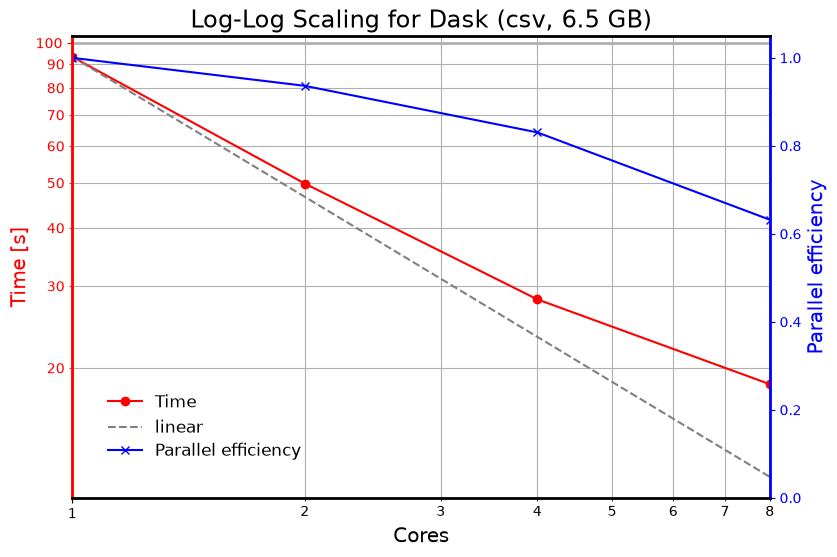

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog()

# time axis
for axis in [ax.xaxis, ax.yaxis]:
    formatter = matplotlib.ticker.FormatStrFormatter("%d")
    axis.set_major_formatter(formatter)
    axis.set_minor_formatter(formatter)
ax.tick_params(axis='y', colors="red", which='both')
ax.grid(visible=True, which='major', linewidth=2)
ax.grid(visible=True, which='minor')

ax.set_title(f"Log-Log Scaling for {dataframe} ({file_format}, {file_size} GB)", fontsize="xx-large")
ax.set_xlabel("Cores", fontsize="x-large")
ax.set_ylabel("Time [s]", fontsize="x-large", color='r')
ax.set_xlim([1, n_cores])
ax.plot(df["cores"].values, df["time"].values, "ro-", label="Time")
ax.plot(df["cores"].values, df["linear"].values, color="gray", linestyle="dashed", label="linear")

# parallel efficiency axis
ax2 = ax.twinx()
ax2.set_ylabel("Parallel efficiency", fontsize="x-large", color="blue")
ax2.tick_params(axis="y", colors="blue", which="both")
ax2.spines["top"].set_linewidth(2)
ax2.spines["bottom"].set_linewidth(2)
ax2.spines["left"].set_linewidth(2)
ax2.spines["left"].set_color("r")
ax2.spines["right"].set_linewidth(2)
ax2.spines["right"].set_color("b")

ax2.set_ylim(0, 1.05)
ax2.plot(df["cores"].values, df["efficiency"].values, "bx-", label="Parallel efficiency")

ax.legend(loc="lower left", bbox_to_anchor=(0.03, 0.1), fontsize="large", frameon=False)
ax2.legend(loc="lower left", bbox_to_anchor=(0.03, 0.05), fontsize="large", frameon=False)

plt.savefig(os.path.join("results",f"{output}.png"), dpi=300)
plt.show()

* Time: observed runtime
* linear: expected runtime for perfect scaling
* Parallel efficiency: measure of resource utilization for parallel processing

For perfect scaling the observed runtime would match the gray dashed line and the parallel efficiency would be 1.0.
